In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import re
import glob
from datetime import datetime

# -------------------------
# Inputs
# -------------------------
contour_file = "contour30sp.csv"

spec_dir = "F:/crs/proj/2025_NOPP_comparison/helene_adcirc_model_results/spec_files/"
spec_files = sorted(glob.glob(spec_dir + "bnd*.spc"))   # bnd1.spc ... bnd425.spc

assume_dirs_are = "to"   # CDIR likely "to"

# Tolerance for optional location sanity check (km)
do_lonlat_check = True
tol_km = 0.2   # 200 m

# Optional time window for curtain plot (None = full span)
t_start = None  # e.g. "2024-09-25 00:00:00"
t_end   = None  # e.g. "2024-09-25 06:00:00"

# -------------------------
# Load contour + normals (your variable names)
# -------------------------
df = pd.read_csv(contour_file)
contour30sp = np.column_stack((df["contour30s_lon"], df["contour30s_lat"]))
normals30sp = np.column_stack((df["normals30_x"], df["normals30_y"]))   # already unit
xy30sp      = np.column_stack((df["contour30s_x"],  df["contour30s_y"]))

npts = contour30sp.shape[0]

print("Contour points:", npts)
print("SPC files found:", len(spec_files))
print("First/last SPC:", Path(spec_files[0]).name, Path(spec_files[-1]).name)


Contour points: 425
SPC files found: 425
First/last SPC: bnd1.spc bnd99.spc


In [3]:
g = 9.81
rho = 1025.0

# ---------- your single haversine (km) ----------
def haversine(lon1, lat1, lon2, lat2):
    """
    Great-circle distance in km.
    lon2/lat2 can be arrays.
    """
    R = 6371.0
    lon1 = np.deg2rad(lon1); lat1 = np.deg2rad(lat1)
    lon2 = np.deg2rad(lon2); lat2 = np.deg2rad(lat2)
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 2.0 * R * np.arcsin(np.sqrt(a))

# ---------- time window parsing ----------
def parse_time_any(t):
    if t is None:
        return None
    if isinstance(t, datetime):
        return t
    for fmt in ("%Y-%m-%d %H:%M:%S", "%Y-%m-%d %H:%M"):
        try:
            return datetime.strptime(t, fmt)
        except Exception:
            pass
    raise ValueError(f"Could not parse time string: {t}")

# ---------- filename -> 1-based index (bnd###.spc) ----------
def bnd_index_1based(fp):
    m = re.search(r"bnd(\d+)$", Path(fp).stem, flags=re.IGNORECASE)
    if not m:
        raise ValueError(f"Could not parse bnd index from filename: {Path(fp).name}")
    return int(m.group(1))

# ---------- SWAN .spc reader (ALL time records) ----------
_float_re = re.compile(r"[-+]?\d*\.\d+(?:[Ee][-+]?\d+)?|[-+]?\d+(?:[Ee][-+]?\d+)?")
_int_re   = re.compile(r"[-+]?\d+")
_time_re  = re.compile(r"^\d{8}\.\d{6}$")  # e.g., 20240925.003000

def _floats_in_line(s):
    return [float(x) for x in _float_re.findall(s)]

def _ints_in_line(s):
    return [int(x) for x in _int_re.findall(s)]

def _parse_swan_time(tok):
    return datetime.strptime(tok, "%Y%m%d.%H%M%S")

def read_swan_spec_vadens_factor(spc_path):
    """
    Reads:
      LONLAT (1 loc), AFREQ (nf), CDIR (nd),
      time records as repeated:
        YYYYMMDD.HHMMSS
        FACTOR
        <float>
        <nf x nd integers>

    Returns dict:
      lon, lat, freqs, dirs, times, E(nt,nf,nd) in m^2/Hz/rad
    """
    spc_path = Path(spc_path)
    lines = spc_path.read_text(errors="ignore").splitlines()

    # LONLAT
    lon = lat = None
    for i, ln in enumerate(lines):
        if ln.strip().startswith("LONLAT"):
            nloc = int(lines[i+1].split()[0])
            if nloc != 1:
                raise ValueError(f"{spc_path.name}: expected 1 location, got {nloc}")
            lon, lat = _floats_in_line(lines[i+2])[:2]
            break
    if lon is None:
        raise ValueError(f"{spc_path.name}: LONLAT not found")

    # AFREQ
    freqs = None
    for i, ln in enumerate(lines):
        if ln.strip().startswith("AFREQ"):
            nf = int(lines[i+1].split()[0])
            vals = []
            j = i + 2
            while len(vals) < nf and j < len(lines):
                vals.extend(_floats_in_line(lines[j]))
                j += 1
            freqs = np.array(vals[:nf], dtype=float)
            break
    if freqs is None:
        raise ValueError(f"{spc_path.name}: AFREQ not found")
    nf = freqs.size

    # CDIR
    dirs = None
    for i, ln in enumerate(lines):
        if ln.strip().startswith("CDIR"):
            nd = int(lines[i+1].split()[0])
            vals = []
            j = i + 2
            while len(vals) < nd and j < len(lines):
                vals.extend(_floats_in_line(lines[j]))
                j += 1
            dirs = np.array(vals[:nd], dtype=float)
            break
    if dirs is None:
        raise ValueError(f"{spc_path.name}: CDIR not found")
    nd = dirs.size

    # Time records
    times = []
    E_list = []

    i = 0
    while i < len(lines):
        s = lines[i].strip()
        if s and _time_re.match(s.split()[0]):
            t = _parse_swan_time(s.split()[0])

            # find FACTOR
            j = i + 1
            while j < len(lines) and not lines[j].strip().startswith("FACTOR"):
                j += 1
            if j >= len(lines):
                break

            factor = float(_floats_in_line(lines[j+1])[0])

            # read nf*nd integers
            vals = []
            k = j + 2
            while k < len(lines) and len(vals) < nf*nd:
                ln = lines[k].strip()
                if ln == "" or ln.startswith("$") or ln.startswith("QUANT") or ln.startswith("VaDens") or ln.startswith("FACTOR"):
                    k += 1
                    continue
                # allow next timestamp to end the read once enough values exist
                if ln and _time_re.match(ln.split()[0]) and len(vals) >= nf*nd:
                    break
                vals.extend(_ints_in_line(ln))
                k += 1

            if len(vals) < nf*nd:
                break

            A = np.array(vals[:nf*nd], dtype=float).reshape((nf, nd))
            E_deg = factor * A               # m^2/Hz/deg
            E_rad = E_deg * (180.0/np.pi)    # m^2/Hz/rad

            times.append(t)
            E_list.append(E_rad)

            i = k
        else:
            i += 1

    if len(times) == 0:
        raise ValueError(f"{spc_path.name}: no time records found")

    E = np.stack(E_list, axis=0)  # (nt,nf,nd)
    return dict(lon=lon, lat=lat, freqs=freqs, dirs=dirs, times=times, E=E)


In [4]:
def hm0_from_E2d(freqs_hz, dirs_deg, E_tfd_rad):
    """
    E_tfd_rad: m^2/Hz/rad, shape (nt,nf,nd)
    """
    f = np.asarray(freqs_hz)
    th = np.deg2rad(np.asarray(dirs_deg))

    df = np.gradient(f)
    dth = np.gradient(th)

    m0 = np.sum(E_tfd_rad * df[None,:,None] * dth[None,None,:], axis=(1,2))
    Hm0 = 4.0 * np.sqrt(m0)
    return Hm0, m0

def flux_vector_from_E2d(freqs_hz, dirs_deg, E_tfd_rad, assume_dirs_are="to"):
    """
    Deep-water energy flux vector components (Fx east, Fy north), W/m.

    Uses Cg = g/(4πf).
    dirs_deg: azimuth clockwise from north.
    assume_dirs_are: "to" or "from" (if "from", rotate +180).
    """
    f = np.asarray(freqs_hz)
    dirs = np.asarray(dirs_deg)

    if assume_dirs_are.lower() == "from":
        dirs = (dirs + 180.0) % 360.0

    theta = np.deg2rad(dirs)

    Cg = g / (4.0 * np.pi * f)  # deep-water
    df = np.gradient(f)
    dth = np.gradient(theta)

    ex = np.sin(theta)  # east
    ny = np.cos(theta)  # north

    W = (rho * g) * (Cg * df)  # (nf,)

    Fx = np.sum(E_tfd_rad * W[None,:,None] * dth[None,None,:] * ex[None,None,:], axis=(1,2))
    Fy = np.sum(E_tfd_rad * W[None,:,None] * dth[None,None,:] * ny[None,None,:], axis=(1,2))
    return Fx, Fy

# ---- establish time axis from bnd1 ----
fp0 = Path(spec_dir) / "bnd1.spc"
rec0 = read_swan_spec_vadens_factor(fp0)
times_ref = rec0["times"]
times_arr = np.array(times_ref)
nt = len(times_ref)

t_start_dt = parse_time_any(t_start)
t_end_dt   = parse_time_any(t_end)

# ---- allocate outputs (rows correspond to contour point order) ----
Fshore_2d = np.full((npts, nt), np.nan, dtype=float)
Hm0_2d    = np.full((npts, nt), np.nan, dtype=float)

# optional lon/lat check stats
dist_km_list = []

# ---- main loop over files ----
for fp in spec_files:
    idx1 = bnd_index_1based(fp)         # 1..npts
    idx0 = idx1 - 1                     # 0..npts-1 (row in contour arrays)

    rec = read_swan_spec_vadens_factor(fp)

    # optional sanity check that file location matches contour point location
    if do_lonlat_check:
        lon_c, lat_c = contour30sp[idx0]
        dkm = float(haversine(rec["lon"], rec["lat"], np.array([lon_c]), np.array([lat_c]))[0])
        dist_km_list.append(dkm)
        if dkm > tol_km:
            raise ValueError(f"{Path(fp).name}: LONLAT is {dkm*1000:.1f} m from contour30sp[{idx0}] (> {tol_km*1000:.0f} m)")

    # Hm0
    Hm0, _ = hm0_from_E2d(rec["freqs"], rec["dirs"], rec["E"])

    # Flux vector (Fx,Fy) then project onto unit normal
    Fx, Fy = flux_vector_from_E2d(rec["freqs"], rec["dirs"], rec["E"], assume_dirs_are=assume_dirs_are)
    nx, ny = normals30sp[idx0]
    Fshore = Fx * nx + Fy * ny

    Hm0_2d[idx0, :]    = Hm0
    Fshore_2d[idx0, :] = Fshore

print("Built arrays:")
print("  Hm0_2d shape   :", Hm0_2d.shape)
print("  Fshore_2d shape:", Fshore_2d.shape)

if do_lonlat_check and len(dist_km_list) > 0:
    dist_km_arr = np.array(dist_km_list)
    print("LONLAT vs contour distances (m) min/mean/max =",
          dist_km_arr.min()*1000, dist_km_arr.mean()*1000, dist_km_arr.max()*1000)


Built arrays:
  Hm0_2d shape   : (425, 145)
  Fshore_2d shape: (425, 145)
LONLAT vs contour distances (m) min/mean/max = 0.0029090284691089523 0.2129300486623432 0.43699985390525437


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def curtain_plot(xy_m, times, curtain, title=None,
                 stride_points=1, stride_time=1,
                 ztick_step=6, s=36,
                 elev=30, azim=250):
    """
    3D 'vertical strip' curtain plot, in the style you shared.

    Parameters
    ----------
    xy_m : (npts,2) array
        Point coordinates in meters (Easting, Northing).
    times : sequence length nt
        datetime objects (or numpy datetime64); used for z tick labels.
    curtain : (npts,nt) array
        Values to color by (e.g., shoreward flux in W/m).
    title : str or None
        Plot title.
    stride_points : int
        Plot every Nth point along the contour (speed/clarity).
    stride_time : int
        Plot every Nth time step (speed/clarity). Labels still based on plotted times.
    ztick_step : int
        Tick spacing in plotted time-index units.
    s : float
        Marker size.
    elev, azim : float
        View angles.
    """
    xy_m = np.asarray(xy_m)
    curtain = np.asarray(curtain)

    # --- subset (optional) ---
    ip = np.arange(0, curtain.shape[0], stride_points)
    it = np.arange(0, curtain.shape[1], stride_time)

    x = xy_m[ip, 0] / 1000.0
    y = xy_m[ip, 1] / 1000.0
    Z = np.arange(it.size)  # plotted time index 0..nt_plot-1
    V = curtain[np.ix_(ip, it)]

    # times subset (keep as python datetimes if possible)
    tplot = np.array(times, dtype=object)[it]

    npts_plot, nt_plot = V.shape

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    # colormap scaling (ignore NaNs)
    norm = plt.Normalize(vmin=np.nanmin(V), vmax=np.nanmax(V))

    # --- plot vertical strips ---
    for i in range(npts_plot):
        time_series = V[i, :]
        x_vals = np.full(nt_plot, x[i])
        y_vals = np.full(nt_plot, y[i])
        sc = ax.scatter(x_vals, y_vals, Z, c=time_series, cmap=cm.hot, norm=norm, s=s)

    # labels
    ax.set_xlabel("Easting (km)")
    ax.set_ylabel("Northing (km)")
    if title is not None:
        ax.set_title(title)

    ax.view_init(elev=elev, azim=azim)

    # colorbar
    cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.08)
    cbar.set_label("Shoreward Wave Energy Flux (W m$^{-1}$)")

    # --- z tick labels ---
    if nt_plot > 1:
        step = int(ztick_step) if ztick_step is not None else max(1, nt_plot // 6)
        zt = np.arange(0, nt_plot, step)

        labels = []
        for k in zt:
            tk = tplot[k]
            # handle datetime64 or datetime
            try:
                labels.append(tk.strftime("%m-%d %H00"))
            except Exception:
                # fallback for numpy datetime64
                labels.append(str(tk)[5:10] + " " + str(tk)[11:13] + "00")

        ax.set_zticks(zt)
        ax.set_zticklabels(labels)

    ax.zaxis.set_tick_params(pad=15)
    plt.show()

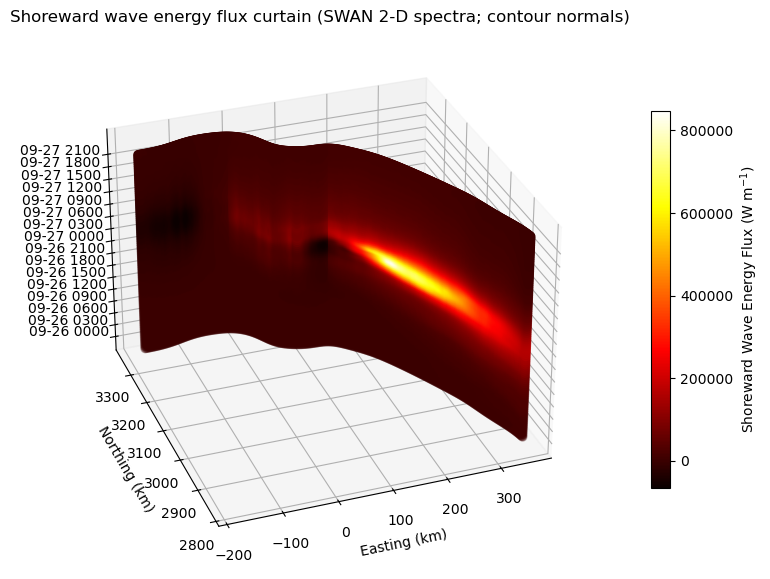

Hm0[0] min/mean/max = 0.28043563549736916 1.4692798686171145 3.9760711148074503
Fshore[0] min/mean/max = -35180.41264526889 -6538.028343645797 -75.94605012320481


In [25]:
# ---- time window mask ----
mask = np.ones(nt, dtype=bool)
if t_start_dt is not None:
    mask &= (times_arr >= t_start_dt)
if t_end_dt is not None:
    mask &= (times_arr <= t_end_dt)

times_plot  = list(times_arr[mask])
Fshore_plot = Fshore_2d[:, mask]
Hm0_plot    = Hm0_2d[:, mask]

# Use the contour lon/lat ordering for the curtain x-axis positions
lons_plot = contour30sp[:, 0]
lats_plot = contour30sp[:, 1]

curtain_plot(
    xy_m=xy30sp,
    times=times_plot[48:97+47],
    curtain=Fshore_plot[:,48:97+47],
    title="Shoreward wave energy flux curtain (SWAN 2-D spectra; contour normals)",
    stride_points=1,   # set to 2,5,10 if you want fewer points drawn
    stride_time=1,     # set to 2 if you want every other time step drawn
    ztick_step=6,      # label every 6 plotted timesteps
    s=36,
    elev=30, azim=250
)

print("Hm0[0] min/mean/max =", Hm0_plot[0,:].min(), Hm0_plot[0,:].mean(), Hm0_plot[0,:].max())
print("Fshore[0] min/mean/max =", Fshore_plot[0,:].min(), Fshore_plot[0,:].mean(), Fshore_plot[0,:].max())


In [44]:
# Kludge alert...this cell may be out of place.
# Investigating the big difference in fluxes between .spc and COAWST calcs...suspect a units or 1/2pi problem.
import numpy as np

g = 9.81
rho = 1025.0

# ----------------------------
# My code from wave_stats.py
# ----------------------------
def calc_kh(w, h):
    g = 9.81
    x = w**2.0 * h / g
    y = np.sqrt(x) * (x < 1.) + x * (x >= 1.)
    t = np.tanh(y)
    y = y - ((y*t - x) / (t + y*(1.0 - t**2.0)))
    t = np.tanh(y)
    y = y - ((y*t - x) / (t + y*(1.0 - t**2.0)))
    t = np.tanh(y)
    y = y - ((y*t - x) / (t + y*(1.0 - t**2.0)))
    return y  # kh

def calc_cp_cg(w, h):
    g = 9.81
    kh = calc_kh(w, h)
    k = kh / h
    cp = np.sqrt((g/k) * np.tanh(kh))
    n = 0.5 * (1.0 + 2*kh/np.sinh(2*kh))
    cg = n * cp
    return cp, cg


def Tp_swan_from_E2d(E_tfd_rad, freqs_hz, dirs_deg, method="TPS"):
    """
    SWAN-style peak period from 2-D variance density spectrum.

    Parameters
    ----------
    E_tfd_rad : (nf,nd) or (nt,nf,nd) array
        2-D spectrum in m^2/Hz/rad (this matches what we built from VaDens with deg->rad conversion).
    freqs_hz : (nf,) array
        Frequencies in Hz.
    dirs_deg : (nd,) array
        Directions in degrees (geographic azimuth, clockwise from north).
        Only used to integrate over direction.

    method : {"RTP","TPS"}
        "RTP": discrete peak period: 1/f at max bin.
        "TPS": SWAN smoothed peak period via parabolic fit through 5 points
               (peak bin +/- 2 bins).

    Returns
    -------
    Tp : (nt,) array
        Peak period in seconds (one value per time record).
    fp : (nt,) array
        Peak frequency in Hz (one value per time record).
    """
    f = np.asarray(freqs_hz, dtype=float)
    th = np.deg2rad(np.asarray(dirs_deg, dtype=float))
    dth = np.gradient(th)

    E = np.asarray(E_tfd_rad, dtype=float)
    if E.ndim == 2:
        E = E[None, :, :]  # (1,nf,nd)

    nt, nf, nd = E.shape

    # 1-D frequency spectrum: S(f) = ∫ E(f,θ) dθ  (units m^2/Hz)
    Sf = np.sum(E * dth[None, None, :], axis=2)  # (nt,nf)

    # Discrete peak index
    jpk = np.argmax(Sf, axis=1)

    fp = np.empty(nt, dtype=float)

    for it in range(nt):
        j = int(jpk[it])

        # RTP: discrete
        if method.upper() == "RTP":
            fp[it] = f[j]
            continue

        # TPS: parabolic fit with 5 points around peak (j-2..j+2)
        # If too close to edges, fall back to discrete
        if j < 2 or j > nf - 3:
            fp[it] = f[j]
            continue

        jj = np.arange(j - 2, j + 3)
        x = f[jj]
        y = Sf[it, jj]

        # Guard: if spectrum is flat/zero, fall back to discrete
        if not np.isfinite(y).all() or np.nanmax(y) <= 0.0:
            fp[it] = f[j]
            continue

        # Quadratic fit y = a x^2 + b x + c
        a, b, c = np.polyfit(x, y, 2)

        # Vertex of parabola
        if a >= 0:  # not a concave-down parabola -> unreliable
            fp[it] = f[j]
            continue

        f_vertex = -b / (2.0 * a)

        # Clamp to the bracketed interval for safety
        fp[it] = np.clip(f_vertex, x.min(), x.max())

    Tp = 1.0 / fp
    return Tp, fp


# ----------------------------
# Spectral moments + flux using your cg
# ----------------------------
def spectral_moments_and_flux(E_tfd_rad, freqs_hz, dirs_deg, h, assume_dirs_are="to"):
    """
    Parameters
    ----------
    E_tfd_rad : (nf,nd) or (nt,nf,nd)
        Variance density spectrum in m^2/Hz/rad.
    freqs_hz : (nf,)
    dirs_deg : (nd,)
        Azimuth clockwise from north.
    h : float
        Water depth (m).
    assume_dirs_are : "to" or "from"
        If "from", rotate directions by +180.

    Returns
    -------
    Hm0 : (nt,)
    Tm10 : (nt,)   # T_{m-1,0}
    Fx, Fy : (nt,) # W/m east, north
    Fmag : (nt,)
    """
    f = np.asarray(freqs_hz, dtype=float)
    dirs = np.asarray(dirs_deg, dtype=float)

    if assume_dirs_are.lower() == "from":
        dirs = (dirs + 180.0) % 360.0

    theta = np.deg2rad(dirs)

    # integration weights
    df = np.gradient(f)
    dth = np.gradient(theta)

    # group velocity from your routine
    w = 2*np.pi*f
    _, cg = calc_cp_cg(w, h)  # (nf,)

    # ensure time axis
    E = np.asarray(E_tfd_rad, dtype=float)
    if E.ndim == 2:
        E = E[None, :, :]  # (1,nf,nd)

    # moments
    m0  = np.sum(E * df[None,:,None] * dth[None,None,:], axis=(1,2))
    m_1 = np.sum((E / f[None,:,None]) * df[None,:,None] * dth[None,None,:], axis=(1,2))  # m_{-1}
    Hm0 = 4.0 * np.sqrt(m0)
    Tm10 = m_1 / m0

    # direction unit vectors (east, north)
    ex = np.sin(theta)
    ny = np.cos(theta)

    # flux vector integral: rho g ∬ Cg E s_hat df dθ
    W = (rho * g) * (cg * df)  # (nf,)
    Fx = np.sum(E * W[None,:,None] * dth[None,None,:] * ex[None,None,:], axis=(1,2))
    Fy = np.sum(E * W[None,:,None] * dth[None,None,:] * ny[None,None,:], axis=(1,2))
    Fmag = np.sqrt(Fx**2 + Fy**2)

    return Hm0, Tm10, Fx, Fy, Fmag


def bulk_flux_from_Hm0_T(Hm0, T, h):
    """
    Bulk flux magnitude F = E * Cg using:
      E = rho g Hm0^2 /16
      Cg from your calc_cp_cg at w=2π/T
    """
    Hm0 = np.asarray(Hm0, dtype=float)
    T = np.asarray(T, dtype=float)

    w = 2*np.pi / T
    _, cg = calc_cp_cg(w, h)

    Ebulk = (rho * g * Hm0**2) / 16.0
    return Ebulk * cg

# ----------------------------
# Example usage for one rec
# ----------------------------
h = 30.0  # set depth for this boundary point (m)
rec = read_swan_spec_vadens_factor(spec_files[0])
Tps, fps = Tp_swan_from_E2d(rec["E"], rec["freqs"], rec["dirs"], method="TPS")

Hm0, Tm10, Fx, Fy, Fmag = spectral_moments_and_flux(rec["E"], rec["freqs"], rec["dirs"], h, assume_dirs_are="to")
Fbulk = bulk_flux_from_Hm0_T(Hm0, Tm10, h)
FbulkTp = bulk_flux_from_Hm0_T(Hm0, Tps, h)

In [41]:
print("Fspec/Fbulk ratio (first 5):", (Fmag[:5] / Fbulk[:5]))
print("Fspec/Fbulk ratio (first 5):", (Fmag[:5] / FbulkTp[:5]))

Fspec/Fbulk ratio (first 5): [0.82664349 0.83138475 0.83560838 0.84184067 0.84670107]
Fspec/Fbulk ratio (first 5): [0.64902928 0.65811505 0.66869836 0.68853651 0.69991964]


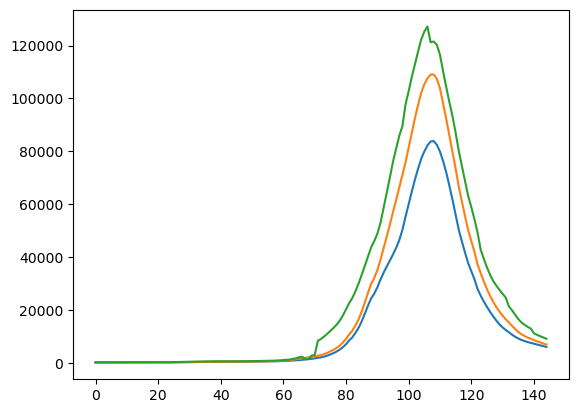

In [42]:
plt.plot(Fmag)
plt.plot(Fbulk)
plt.plot(FbulkTp)

In [50]:
Tp_TPS, fp_TPS = Tp_swan_from_E2d(rec["E"], rec["freqs"], rec["dirs"], method="TPS")
Tp_RTP, fp_RTP = Tp_swan_from_E2d(rec["E"], rec["freqs"], rec["dirs"],  method="RTP")

ilist = np.arange( 100, 120 )
print(ilist)

for i in ilist:
    print(
        i,
        "Tm-10=", f"{Tm10[i]:6.2f}s",
        "Tp_RTP=", f"{Tp_RTP[i]:6.2f}s (fp={fp_RTP[i]:.4f} Hz)",
        "Tp_TPS=", f"{Tp_TPS[i]:6.2f}s (fp={fp_TPS[i]:.4f} Hz)"
    )


[100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119]
100 Tm-10=  10.97s Tp_RTP=  14.86s (fp=0.0673 Hz) Tp_TPS=  14.27s (fp=0.0701 Hz)
101 Tm-10=  11.17s Tp_RTP=  14.86s (fp=0.0673 Hz) Tp_TPS=  14.34s (fp=0.0698 Hz)
102 Tm-10=  11.35s Tp_RTP=  14.86s (fp=0.0673 Hz) Tp_TPS=  14.38s (fp=0.0695 Hz)
103 Tm-10=  11.50s Tp_RTP=  14.86s (fp=0.0673 Hz) Tp_TPS=  14.42s (fp=0.0694 Hz)
104 Tm-10=  11.59s Tp_RTP=  14.86s (fp=0.0673 Hz) Tp_TPS=  14.41s (fp=0.0694 Hz)
105 Tm-10=  11.68s Tp_RTP=  14.86s (fp=0.0673 Hz) Tp_TPS=  14.40s (fp=0.0695 Hz)
106 Tm-10=  11.77s Tp_RTP=  14.86s (fp=0.0673 Hz) Tp_TPS=  14.38s (fp=0.0696 Hz)
107 Tm-10=  11.79s Tp_RTP=  13.51s (fp=0.0740 Hz) Tp_TPS=  13.98s (fp=0.0715 Hz)
108 Tm-10=  11.76s Tp_RTP=  13.51s (fp=0.0740 Hz) Tp_TPS=  13.91s (fp=0.0719 Hz)
109 Tm-10=  11.70s Tp_RTP=  13.51s (fp=0.0740 Hz) Tp_TPS=  13.85s (fp=0.0722 Hz)
110 Tm-10=  11.67s Tp_RTP=  13.51s (fp=0.0740 Hz) Tp_TPS=  13.79s (fp=0.0725 Hz)
111 Tm-10=  11.66s Tp_RTP=

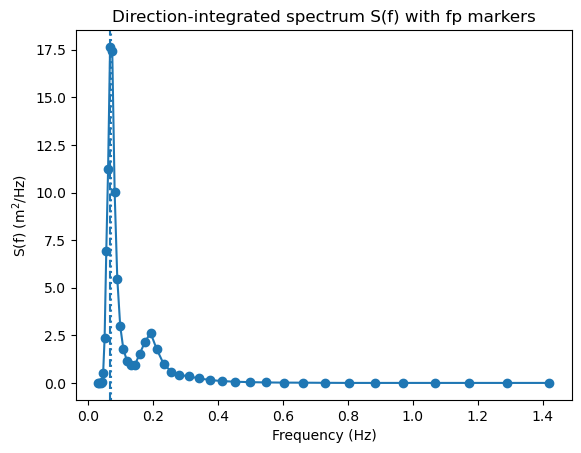

In [52]:
import matplotlib.pyplot as plt
theta = np.deg2rad(rec["dirs"])
dth = np.gradient(theta)

it = 100  # pick a time index
Sf = np.sum(rec["E"][it,:,:] * dth[None,:], axis=1)  # (nf,)

plt.figure()
plt.plot(rec["freqs"], Sf, marker='o')
plt.axvline(fp_RTP[it], linestyle='--')
plt.axvline(fp_TPS[it], linestyle=':')
plt.xlabel("Frequency (Hz)")
plt.ylabel("S(f) (m$^2$/Hz)")
plt.title("Direction-integrated spectrum S(f) with fp markers")
plt.show()
